In [2]:
#Scenario:
# investigating the link between carbon emissions and rising temperatures. Your job is to model whether countries with higher CO₂ emissions per capita also experience greater temperature anomalies.

In [3]:
#Step 1 Creating Mock Data
# Create mock data
set.seed(123)

co2 <- runif(50, min = 2, max = 20)  # CO₂ emissions per capita (in tonnes)
temperature_anomaly <- 0.3 * co2 + #Applies the slope
    rnorm(50, mean = 0, sd = 1.5) #Add real world messiness

#0.3 is the regression line, the predicted temperature based on CO2. So Its the slope.
#Note: Slope * x_variable + rnorm()

climate_df <- data.frame( #Packages into a neat spreadsheet
  co2,
  temperature_anomaly
)

head(climate_df)

,co2,temperature_anomaly
,<dbl>,<dbl>
1,7.176395,-0.3771214
2,16.189492,6.1135283
3,9.361585,3.0385351
4,17.894313,3.6610886
5,18.928411,7.5592457
6,2.820017,1.4857014


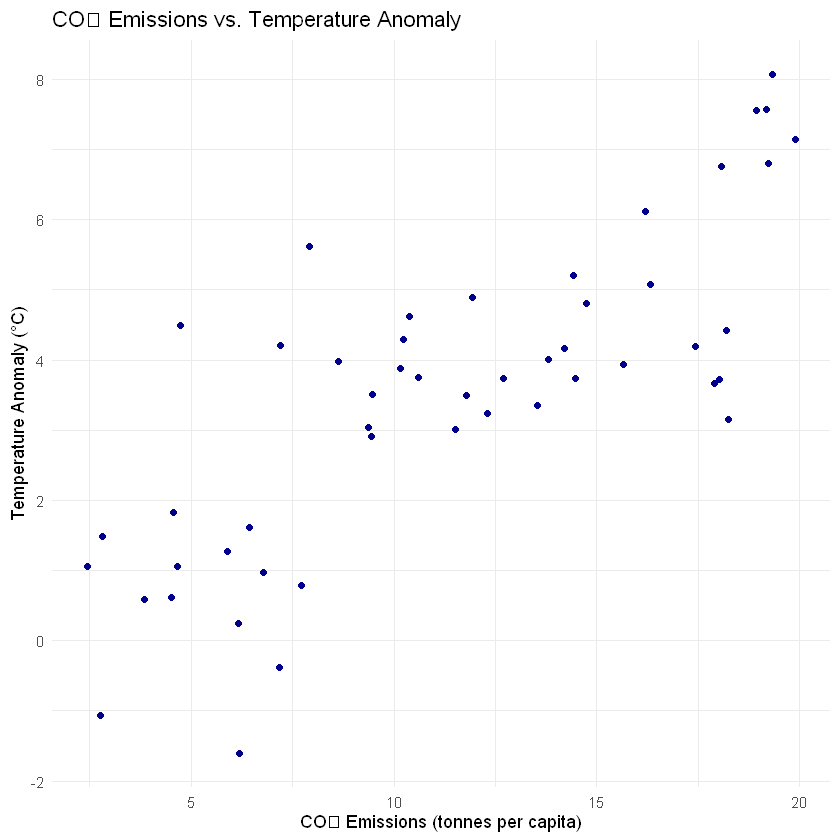

In [4]:
#Step 2 Visualising the Data
#helps us visually confirm whether a linear relationship exists.
library(ggplot2)

ggplot(climate_df, aes(x = co2, y = temperature_anomaly)) +
  geom_point(color = "darkblue") +
  labs(
    title = "CO₂ Emissions vs. Temperature Anomaly",
    x = "CO₂ Emissions (tonnes per capita)",
    y = "Temperature Anomaly (°C)"
  ) +
  theme_minimal()

In [5]:
#Step 3 Fitting a Linear Regression Model
# Fit the model
model <- lm(temperature_anomaly ~ co2, data = climate_df)

# Display model summary
summary(model)


Call:
lm(formula = temperature_anomaly ~ co2, data = climate_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.3837 -0.8368 -0.0985  0.8239  3.2792 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.27715    0.47601  -0.582    0.563    
co2          0.33181    0.03804   8.723 1.82e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.411 on 48 degrees of freedom
Multiple R-squared:  0.6132,	Adjusted R-squared:  0.6051 
F-statistic: 76.08 on 1 and 48 DF,  p-value: 1.822e-11


`geom_smooth()` using
formula = 'y ~ x'


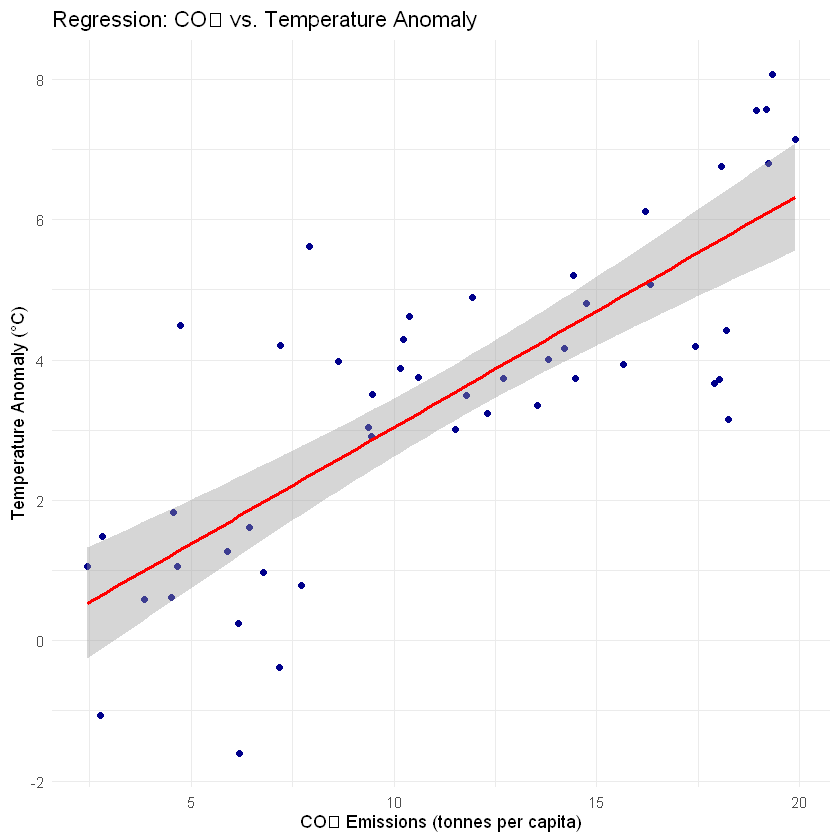

In [6]:
#Add the Regression Line to the PLot
ggplot(climate_df, aes(x = co2, y = temperature_anomaly)) +
  geom_point(color = "darkblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = "Regression: CO₂ vs. Temperature Anomaly",
    x = "CO₂ Emissions (tonnes per capita)",
    y = "Temperature Anomaly (°C)"
  ) +
  theme_minimal()

In [11]:
#Is the slope positive or negative?
print("The slope is 0.33181, so positiive")

[1] "The slope is 0.33181, so positiive"


In [13]:
#What does the R-squared value tell you?
print("The adjusted R-squared value is 0.6051. Meaning that approx. 61% of CO2 emissions explain the variation in tempeerature anomaly.")

[1] "The adjusted R-squared value is 0.6051. Meaning that approx. 61% of CO2 emissions explain the variation in tempeerature anomaly."


In [15]:
#Is the relationship statistically significant (check the p-value)?
print("The p_value is statistically significant as it is < 0.05. Being  0.00000000001822. CO₂ is a meaningful predictor of temperature anomaly.")

[1] "The p_value is statistically significant as it is < 0.05. Being  0.00000000001822. CO₂ is a meaningful predictor of temperature anomaly."


In [16]:
#If CO₂ emissions increase by 5 tonnes per capita, what would the model predict?
co2_estimate <-  0.33181 
slope <- (co2_estimate * 5)
intercept <- -0.27715
predicted_temp <- slope + intercept
print("If CO2 emissions increase by 5 tonnes per capita, the model predicts a temperature of:")
print(predicted_temp)

[1] "If CO2 emissions increase by 5 tonnes per capita, the model predicts a temperature of:"
[1] 1.3819
